# Domain invariance in the latent space — teacher vs student

Adapted from `domain_gap_terramind.ipynb`. That notebook compared a *pretrained*
against a *fine-tuned* TerraMind encoder; this one compares the **TerraMind
teacher** against the **distilled U-Net student**, to ask whether cross-sensor
contrastive KD actually produced a more sensor-invariant representation.

**Checkpoints**
- teacher — `terramind_v1_base` fine-tuned on Sentinel-2B WorldCover
- student — cross-sensor KD run `inst0.0/pix0.0` **+ DSBN**, focal + `inverse_sqrt` weights,
  epoch 46 (val mIoU 0.3916, test target mIoU 0.4146) — the best run to date

Because this student uses domain-specific BatchNorm, each domain is forwarded
through its own normalisation branch (`set_domain`), exactly as in training.
This makes the encoder domain-*adaptive*, not domain-*invariant*: read the PAD
numbers as \"how separable are the domains after per-domain normalisation\".

**Two things done differently from the source notebook, on purpose**

1. *Normalisation is imported from the training pipeline* rather than re-derived.
   The source notebook hand-rolled `sqrt -> clip -> z-score`; if those constants
   drift from `DOMAIN_STATS` the models get evaluated on a distribution they were
   never trained on, and the domain gap you measure is partly your own
   preprocessing. Here `PhisatPairedLULCDataset` produces the tensors, so the
   normalisation is bit-identical to training by construction.

2. *MMD is not used to compare the two models directly.* The teacher embedding is
   a 768-d ViT token average; the student's is a U-Net bottleneck pooled to a few
   hundred channels. RBF-MMD with fixed bandwidths (the `sigmas=[1,2,4,8,16]` of
   the source notebook) is **scale-dependent**, so those two numbers are not on a
   common axis and ranking them would be an artefact. Instead:
   - **MMD²** with a *median-heuristic* bandwidth (Gretton et al. 2012), reported
     **within** each model, where it is a valid measure of how far apart the two
     sensor distributions sit.
   - **Proxy A-distance** (Ben-David et al. 2010) for the **across-model**
     comparison: train a domain classifier on the embeddings and report
     `PAD = 2(1 - 2*err)`. It is invariant to any invertible rescaling of the
     space, so teacher and student are genuinely comparable. `PAD = 0` means the
     two sensors are indistinguishable (domain-invariant); `PAD = 2` means
     perfectly separable.


In [2]:
import sys
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

REPO = Path("/shared/home/elucas/scratch/terra-sat-drift")
sys.path.insert(0, str(REPO / "terra_sat_drift"))
sys.path.insert(0, str(REPO / "scripts" / "dataset_report"))

TEACHER_CKPT = REPO / "outputs/terramind_v1_base_pretrain_s2b_lulc/checkpoints/best-val_mIoU-v6.ckpt"
STUDENT_CKPT = "/shared/home/elucas/scratch/terra-sat-drift/outputs/xsensor_kd_terramind_v1_base_kd1.0_inst0.1_pix0.0_dsbn/checkpoints/best-58-0.4138.ckpt"
BACKBONE = "terramind_v1_base"
NUM_CLASSES = 11

# `test`, not `val`: the student checkpoint was *selected* on val, so val would
# flatter it slightly. Neither model trained on either.
SPLIT = "test"
N_SAMPLES = 800      # patches; each costs 3 teacher + 3 student forwards
BATCH = 8

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# Slots 1-3 of the project's validated categorical palette. Scatter plots compare
# every pair of series at once, and only these three clear that gate -- do not add
# a fourth generated hue here.
DOMAIN_COLOR = {"real": "#2a78d6", "sim": "#1baf7a", "s2b": "#eb6834"}
DOMAIN_LABEL = {"real": "PhiSat-2 (real)", "sim": "PhiSat-2 (simulated)", "s2b": "Sentinel-2B"}

# DSBN branch routing, matching kd_contrastive_module. Getting this wrong is
# silent: the model still runs, it just normalises PhiSat-2 with Sentinel-2
# moments and the measured "domain gap" becomes an artefact of the mistake.
SOURCE_DOMAIN_ID, TARGET_DOMAIN_ID = 0, 1
DOMAIN_BRANCH = {
    "real": TARGET_DOMAIN_ID,   # what the student was trained to deploy on
    "s2b": SOURCE_DOMAIN_ID,    # the teacher's home domain
    # `sim` was never seen in training. It is radiometrically Sentinel-2 (its
    # per-band statistics match s2b to ~0.01), so it is routed through the
    # source branch. Flagged because it is a judgement call, not a given.
    "sim": SOURCE_DOMAIN_ID,
}

device: cuda


## 1. Data

`PhisatPairedLULCDataset` applies the per-domain `sqrt -> clip -> z-score` from
`DOMAIN_STATS`. Two instances share the same split and seed, so index `i` refers
to the same ground in both, which is what makes the paired cosine meaningful.

In [3]:
from dataset.dataset_paired_triplets_lulc import DOMAIN_STATS, PhisatPairedLULCDataset

DATA = Path("/shared/projects/phisat2/data/processed")
_kw = dict(
    h5_images_path=str(DATA / "triplets_v1/phisat2_s2b_dataset_v1.h5"),
    h5_labels_path=str(DATA / "worldcover_all_clean_v1/worldcover_all_clean_labels_v1.h5"),
    manifest_path=str(DATA / "worldcover_all_clean_v1/worldcover_all_clean_manifest_v1.csv"),
    split=SPLIT,
    transform=None,          # no augmentation: this is a measurement, not training
)
ds_real = PhisatPairedLULCDataset(target_domain="real", source_domain="s2b", **_kw)
ds_sim = PhisatPairedLULCDataset(target_domain="sim", source_domain="s2b", **_kw)
assert len(ds_real) == len(ds_sim)
print(f"{len(ds_real):,} {SPLIT} patches; using {min(N_SAMPLES, len(ds_real)):,}")

for name, st in DOMAIN_STATS.items():
    print(f"  {name:5s} clip={st['clip']:<7} mean[0]={st['mean'][0]:.3f}")

25,323 test patches; using 800
  real  clip=38.729  mean[0]=14.531
  s2b   clip=100.0   mean[0]=49.021
  sim   clip=100.0   mean[0]=49.025


## 2. Teacher

Built with the same factory the KD script uses, so the architecture matches the checkpoint exactly.

In [4]:
from kd_lulc_contrastive import build_teacher_model   # safe: guarded by __main__

teacher = build_teacher_model(BACKBONE, NUM_CLASSES, str(TEACHER_CKPT)).to(device).eval()
for p in teacher.parameters():
    p.requires_grad_(False)

Loading teacher weights from: /shared/home/elucas/scratch/terra-sat-drift/outputs/terramind_v1_base_pretrain_s2b_lulc/checkpoints/best-val_mIoU-v6.ckpt
  missing keys: 0, unexpected keys: 0


## 3. Student

The KD checkpoint stores the whole `CrossSensorKDModule`, so it also contains the
frozen teacher and the projection heads. Only the `student.` subtree is loaded
here. `load_state_dict` is checked rather than trusted: a silently mismatched
student would produce a perfectly plausible-looking — and meaningless — plot.

In [5]:
from model_tasks.domain_adaptation.dsbn import convert_to_dsbn, set_domain
from student_mobilenet import create_student_model

_ck = torch.load(STUDENT_CKPT, map_location="cpu", weights_only=False)
print("checkpoint epoch:", _ck.get("epoch"), "| global_step:", _ck.get("global_step"))
_sd = {k[len("student."):]: v for k, v in _ck["state_dict"].items() if k.startswith("student.")}

# Detected from the weights rather than read from hparams, so a checkpoint
# saved by an older module version still loads correctly.
STUDENT_IS_DSBN = any(".bns." in k for k in _sd)
print("DSBN student:", STUDENT_IS_DSBN, f"({sum('.bns.' in k for k in _sd)} DSBN tensors)")

student = create_student_model(in_channels=7, num_classes=NUM_CLASSES)
if STUDENT_IS_DSBN:
    # Every BatchNorm2d becomes one branch per domain; without this the shapes
    # still match but the keys do not, and strict=True below would catch it.
    convert_to_dsbn(student, num_domains=2)

missing, unexpected = student.load_state_dict(_sd, strict=True)
print(f"loaded {len(_sd)} tensors; missing={list(missing)} unexpected={list(unexpected)}")
if "class_weight" in _ck["state_dict"]:
    print("class weights in ckpt:", np.round(_ck["state_dict"]["class_weight"].numpy(), 3))

student = student.to(device).eval()
for p in student.parameters():
    p.requires_grad_(False)
del _ck, _sd

checkpoint epoch: 58 | global_step: 73750
DSBN student: True (220 DSBN tensors)
loaded 244 tensors; missing=[] unexpected=[]
class weights in ckpt: [0.332 0.605 0.325 0.405 0.391 0.369 2.104 0.594 1.243 2.055 2.578]


## 4. Embeddings

One pooled vector per patch per model, matching what the contrastive objective
operated on during training:

- **teacher** — last encoder block's token sequence, averaged over tokens.
- **student** — U-Net bottleneck (`stages[0]`, the deepest encoder output),
  global-average-pooled. This is the tensor `w_instance` was applied to.

In [6]:
def _pool(feat):
    """(B,C,H,W) or (B,N,D) -> (B,C). Mirrors CrossSensorKDModule._pool."""
    if isinstance(feat, (list, tuple)):
        feat = feat[-1]
    if feat.dim() == 4:
        return F.adaptive_avg_pool2d(feat, 1).flatten(1)
    if feat.dim() == 3:
        return feat.mean(dim=1)
    return feat


@torch.no_grad()
def teacher_embed(x):
    return _pool(teacher.encoder({"S2L1C": x}))


@torch.no_grad()
def student_embed(x, domain):
    """`domain` selects the DSBN branch; ignored by a non-DSBN student.

    With DSBN the encoder is domain-*adaptive* rather than domain-*invariant*:
    conv weights are shared but each domain carries its own normalisation
    statistics, so the branch must be selected explicitly at inference.
    """
    if STUDENT_IS_DSBN:
        set_domain(student, DOMAIN_BRANCH[domain])
    return _pool(student(x, return_features=True)["bottleneck"])


@torch.no_grad()
def extract(n=N_SAMPLES, batch=BATCH):
    """Returns {model: {domain: (n, D)}} plus the patch indices used."""
    n = min(n, len(ds_real))
    out = {m: {d: [] for d in ("real", "sim", "s2b")} for m in ("teacher", "student")}
    idx = []
    for start in range(0, n, batch):
        sl = range(start, min(start + batch, n))
        xr = torch.stack([ds_real[i]["image_target"] for i in sl]).to(device)
        xm = torch.stack([ds_sim[i]["image_target"] for i in sl]).to(device)
        xs = torch.stack([ds_real[i]["image_source"] for i in sl]).to(device)
        idx += [int(ds_real[i]["patch_index"]) for i in sl]
        for dom, x in (("real", xr), ("sim", xm), ("s2b", xs)):
            out["teacher"][dom].append(teacher_embed(x).float().cpu())
            out["student"][dom].append(student_embed(x, dom).float().cpu())
        if start % (batch * 20) == 0:
            print(f"  {start + len(sl)}/{n}", end="\r")
    emb = {m: {d: torch.cat(v).numpy() for d, v in dd.items()} for m, dd in out.items()}
    print()
    for m in emb:
        print(f"{m:8s} embedding dim = {emb[m]['real'].shape[1]}")
    return emb, np.asarray(idx)


emb, patch_idx = extract()

  648/800
teacher  embedding dim = 768
student  embedding dim = 512


## 5. Metrics

**MMD²** — unbiased estimator with a median-heuristic bandwidth. Read *down* a
column (how far apart the sensors are inside one model), not across rows.

**Proxy A-distance** — the cross-model number. Logistic regression on
standardised embeddings, held-out error, `PAD = 2(1 - 2*err)`.

**Paired cosine** — same patch, two sensors. Scale-free, so comparable across
models, and the direct analogue of the `cos_paired` logged during training.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler


def mmd2_rbf(X, Y, bandwidth=None):
    """Unbiased MMD^2 with an RBF kernel.

    `bandwidth` is sigma^2 * 2; when None it is set by the median heuristic --
    the median squared pairwise distance over the pooled sample. Fixed
    bandwidths make MMD scale-dependent and therefore incomparable between two
    differently-scaled embedding spaces, which is exactly the trap here.
    """
    X = torch.as_tensor(X, dtype=torch.float64)
    Y = torch.as_tensor(Y, dtype=torch.float64)
    Z = torch.cat([X, Y], 0)
    d2 = torch.cdist(Z, Z).pow(2)
    if bandwidth is None:
        off = d2[~torch.eye(len(Z), dtype=bool)]
        bandwidth = off.median().clamp_min(1e-12)
    K = torch.exp(-d2 / bandwidth)
    n, m = len(X), len(Y)
    Kxx, Kyy, Kxy = K[:n, :n], K[n:, n:], K[:n, n:]
    exx = (Kxx.sum() - Kxx.diagonal().sum()) / (n * (n - 1))
    eyy = (Kyy.sum() - Kyy.diagonal().sum()) / (m * (m - 1))
    return float(exx + eyy - 2 * Kxy.mean())


def proxy_a_distance(X, Y, seed=0):
    """PAD in [0, 2]; 0 = domains indistinguishable, 2 = perfectly separable."""
    Z = StandardScaler().fit_transform(np.vstack([X, Y]))
    y = np.r_[np.zeros(len(X)), np.ones(len(Y))]
    clf = LogisticRegression(max_iter=2000, random_state=seed)
    err = 1.0 - cross_val_score(clf, Z, y, cv=5, scoring="accuracy").mean()
    return float(2 * (1 - 2 * err)), err


def paired_cosine(X, Y):
    a = F.normalize(torch.as_tensor(X), dim=1)
    b = F.normalize(torch.as_tensor(Y), dim=1)
    return float((a * b).sum(1).mean())


rows = []
for model in ("teacher", "student"):
    e = emb[model]
    for a, b in (("real", "s2b"), ("sim", "s2b"), ("real", "sim")):
        pad, err = proxy_a_distance(e[a], e[b])
        rows.append({
            "model": model, "pair": f"{a} vs {b}",
            "MMD2 (median-h)": mmd2_rbf(e[a], e[b]),
            "PAD": pad, "domain-clf err": err,
            "paired cosine": paired_cosine(e[a], e[b]),
        })

import pandas as pd
tbl = pd.DataFrame(rows)
display(tbl.round(4))

,model,pair,MMD2 (median-h),PAD,domain-clf err,paired cosine
0,teacher,real vs s2b,0.1284,1.9825,0.0044,0.3071
1,teacher,sim vs s2b,0.0008,1.1300,0.2175,0.9523
2,teacher,real vs sim,0.1187,1.9625,0.0094,0.3346
3,student,real vs s2b,0.0169,2.0000,0.0000,0.9226
4,student,sim vs s2b,0.0082,1.0150,0.2463,0.9783
5,student,real vs sim,0.0259,2.0000,0.0000,0.9094


### Reading the table

`real vs s2b` is the gap that matters — it is the shift the deployed student
faces. `sim vs s2b` is a floor: the simulated view *is* Sentinel-2 put through a
sensor model, so anything much above zero there is the simulator's spatial
effect rather than a true domain gap. A student that achieved sensor invariance
should show a **lower PAD on `real vs s2b` than the teacher does**.

### PAD is the wrong instrument once DSBN is on

A DSBN student gives each domain its own BatchNorm affine and running statistics,
so the two domains are produced by **different affine maps**. A difference in the
BatchNorm shift is a constant per-domain offset, which a linear probe separates
perfectly — `PAD` saturates at 2 for *any* DSBN model regardless of how well the
semantics line up. It stays valid for the teacher and for non-DSBN students.

The two cells below separate the artefact from the substance:

1. **PAD after standardising each domain on its own statistics** — removes exactly
   the first and second moments DSBN is licensed to differ in. If this collapses
   to chance the raw separability *was* the affine. (At chance, `PAD = 0`;
   slightly negative just means the probe did no better than chance, so read
   `<= 0` as "no linear domain signal", not as a magnitude.)
2. **Cross-domain probe transfer** — the functional question. Fit a patch-level
   linear classifier on Sentinel-2 embeddings and apply it to PhiSat-2 embeddings
   of the same patches. Retention = cross-domain accuracy / same-domain accuracy.
   This is what "domain-invariant representation" should mean operationally: does
   structure learned on the source remain readable on the target.


In [8]:
def pad_per_domain_standardised(X, Y):
    """PAD after each domain is standardised on its own moments."""
    Z = np.vstack([StandardScaler().fit_transform(X), StandardScaler().fit_transform(Y)])
    t = np.r_[np.zeros(len(X)), np.ones(len(Y))]
    err = 1 - cross_val_score(LogisticRegression(max_iter=3000), Z, t, cv=5).mean()
    return float(2 * (1 - 2 * err))


def probe_transfer(X_src, X_tgt, y, train_frac=0.7, seed=0):
    """Fit on source embeddings, score on source and on target (same patches)."""
    ok = y >= 0
    Xs, Xt, yy = X_src[ok], X_tgt[ok], y[ok]
    idx = np.random.default_rng(seed).permutation(len(yy))
    tr, te = idx[:int(train_frac * len(yy))], idx[int(train_frac * len(yy)):]
    sc = StandardScaler().fit(Xs[tr])
    clf = LogisticRegression(max_iter=3000).fit(sc.transform(Xs[tr]), yy[tr])
    same = clf.score(sc.transform(Xs[te]), yy[te])
    cross = clf.score(sc.transform(Xt[te]), yy[te])
    return same, cross


# Patch-level label = the dominant WorldCover class, for the probe.
y_dom = []
for i in range(len(emb["student"]["real"])):
    m = ds_real[i]["mask"].numpy()
    m = m[m >= 0]
    y_dom.append(np.bincount(m, minlength=NUM_CLASSES).argmax() if m.size else -1)
y_dom = np.asarray(y_dom)

rows2 = []
for model in ("teacher", "student"):
    R, S = emb[model]["real"], emb[model]["s2b"]
    same, cross = probe_transfer(S, R, y_dom)
    rows2.append({
        "model": model,
        "PAD (raw)": tbl[(tbl.model == model) & (tbl.pair == "real vs s2b")]["PAD"].iloc[0],
        "PAD (per-domain std)": pad_per_domain_standardised(R, S),
        "paired cosine": paired_cosine(R, S),
        "probe s2b->s2b": same,
        "probe s2b->real": cross,
        "retention": cross / max(same, 1e-9),
    })
display(pd.DataFrame(rows2).round(4))

,model,PAD (raw),PAD (per-domain std),paired cosine,probe s2b->s2b,probe s2b->real,retention
0,teacher,1.9825,-1.155,0.3071,0.8458,0.2292,0.2709
1,student,2.0000,-0.860,0.9226,0.6958,0.6958,1.0000


### Seeing what PAD measures

`PAD` is a one-number summary of a domain probe's held-out error, so the honest
way to read it is to look at the quantity it summarises: the probe's decision
score for each domain. Two separated humps means the probe never errs
(`PAD -> 2`); two overlapping humps means it is guessing (`PAD -> 0`).

The `per-domain standardised` column re-fits a **separate** scaler on each domain,
forcing both to mean 0 and unit variance per dimension. That deletes exactly the
first and second marginal moments — which is precisely what a per-domain
BatchNorm affine is. Whatever separability survives is *structural*: different
correlations between dimensions, different distribution shape.

So the pair decomposes the gap:
`raw = affine offset + structure`, `standardised = structure alone`.

One caveat: standardising per domain also erases a *genuine* uncorrected mean
shift, not just a benign DSBN affine. Read `standardised ≈ chance` as "nothing
beyond first/second moments distinguishes the domains", **not** as "the domains
are identical". The probe-transfer number above is what carries the operational
claim.


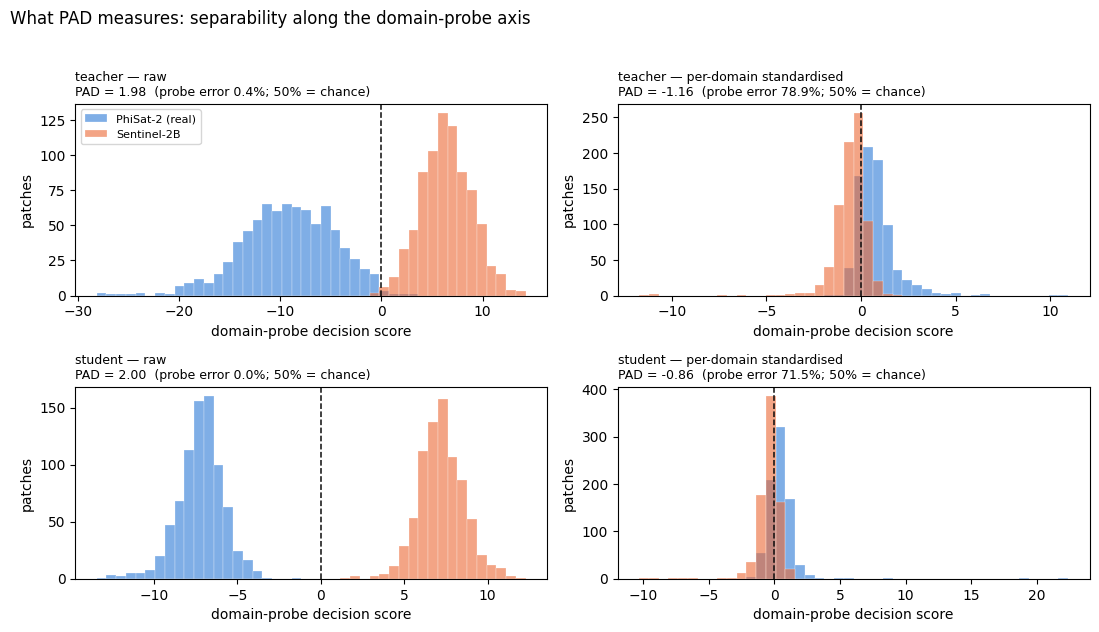

In [9]:
from sklearn.model_selection import cross_val_predict

def domain_scores(X, Y, per_domain):
    """Out-of-fold decision scores of the domain probe, and the resulting PAD."""
    Z = (np.vstack([StandardScaler().fit_transform(X), StandardScaler().fit_transform(Y)])
         if per_domain else StandardScaler().fit_transform(np.vstack([X, Y])))
    t = np.r_[np.zeros(len(X)), np.ones(len(Y))]
    clf = LogisticRegression(max_iter=3000)
    s = cross_val_predict(clf, Z, t, cv=5, method="decision_function")
    err = 1 - cross_val_score(clf, Z, t, cv=5).mean()
    return s[:len(X)], s[len(X):], 2 * (1 - 2 * err), err


fig, axes = plt.subplots(2, 2, figsize=(11, 6.4))
pad_res = {}
for r, model in enumerate(("teacher", "student")):
    for c, per_dom in enumerate((False, True)):
        ax = axes[r][c]
        sr, ss, pad, err = domain_scores(emb[model]["real"], emb[model]["s2b"], per_dom)
        pad_res[(model, per_dom)] = pad
        bins = np.linspace(min(sr.min(), ss.min()), max(sr.max(), ss.max()), 45)
        for dom, v in (("real", sr), ("s2b", ss)):
            ax.hist(v, bins=bins, color=DOMAIN_COLOR[dom], alpha=0.6,
                    label=DOMAIN_LABEL[dom], edgecolor="white", linewidth=0.3)
        ax.axvline(0, color="#0b0b0b", lw=1.1, ls="--")
        ax.set_xlabel("domain-probe decision score")
        ax.set_ylabel("patches")
        ax.set_title(f"{model} — {'per-domain standardised' if per_dom else 'raw'}\n"
                     f"PAD = {pad:.2f}  (probe error {err:.1%}; 50% = chance)",
                     loc="left", fontsize=9)
        if r == 0 and c == 0:
            ax.legend(fontsize=8)
fig.suptitle("What PAD measures: separability along the domain-probe axis", x=0.005, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

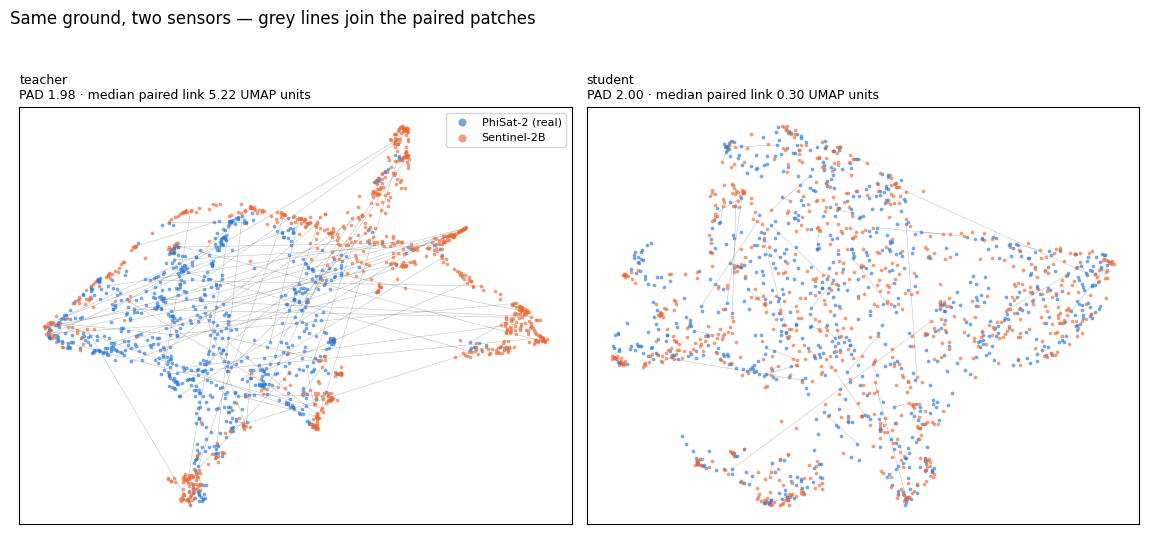

In [11]:
# Paired links: same ground, two sensors. A short link means the two views land
# in the same place; the median link length makes it quantitative rather than
# just visual.
import umap

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.4))
rng = np.random.default_rng(0)
link = rng.choice(len(emb["student"]["real"]), 70, replace=False)
for ax, model in zip(axes, ("teacher", "student")):
    X = StandardScaler().fit_transform(np.vstack([emb[model]["real"], emb[model]["s2b"]]))
    Z = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=0).fit_transform(X)
    n = len(emb[model]["real"])
    Zr, Zs = Z[:n], Z[n:]
    for i in link:
        ax.plot([Zr[i, 0], Zs[i, 0]], [Zr[i, 1], Zs[i, 1]],
                color="#52514e", lw=0.4, alpha=0.35, zorder=1)
    for dom, Zd in (("real", Zr), ("s2b", Zs)):
        ax.scatter(Zd[:, 0], Zd[:, 1], s=7, c=DOMAIN_COLOR[dom], alpha=0.65,
                   linewidths=0, label=DOMAIN_LABEL[dom], zorder=2)
    med = np.median(np.linalg.norm(Zr - Zs, axis=1))
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.set_title(f"{model}\nPAD {pad_res[(model, False)]:.2f} · "
                 f"median paired link {med:.2f} UMAP units", loc="left", fontsize=9)
    if model == "teacher":
        ax.legend(markerscale=2.2, fontsize=8)
fig.suptitle("Same ground, two sensors — grey lines join the paired patches",
             x=0.005, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

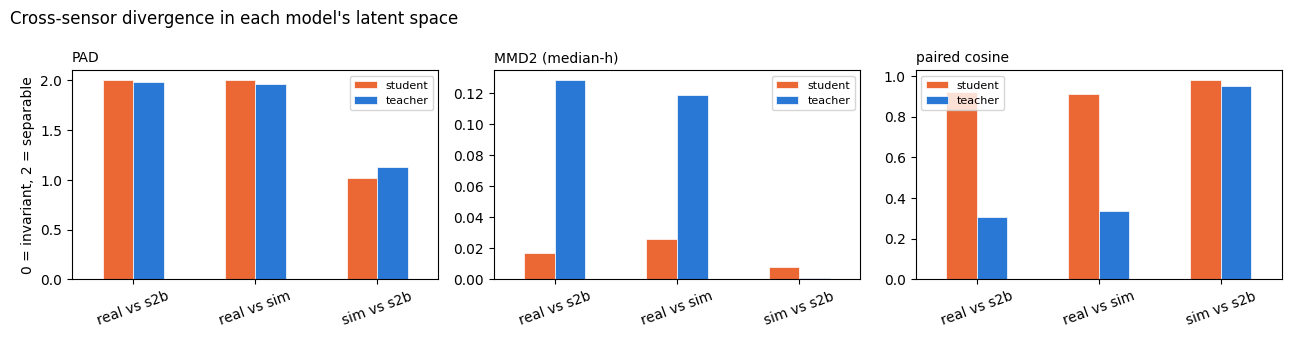

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, metric in zip(axes, ["PAD", "MMD2 (median-h)", "paired cosine"]):
    p = tbl.pivot(index="pair", columns="model", values=metric)
    p.plot.bar(ax=ax, color=["#eb6834", "#2a78d6"], edgecolor="white", linewidth=0.5, rot=20)
    ax.set_title(metric, loc="left", fontsize=10)
    ax.set_xlabel("")
    ax.grid(axis="x", visible=False)
    ax.legend(fontsize=8)
axes[0].set_ylabel("0 = invariant, 2 = separable")
fig.suptitle("Cross-sensor divergence in each model's latent space", x=0.01, ha="left")
fig.tight_layout()
plt.show()

## 6. 2-D projection

UMAP for the main view (it preserves global structure better than t-SNE, so
between-cluster distances carry some meaning), with t-SNE alongside for
continuity with the original notebook. Each model is projected **separately** —
a shared projection of two different embedding spaces would be meaningless.

Both are fitted on the concatenation of the three domains so the domains share
one projection within a model.

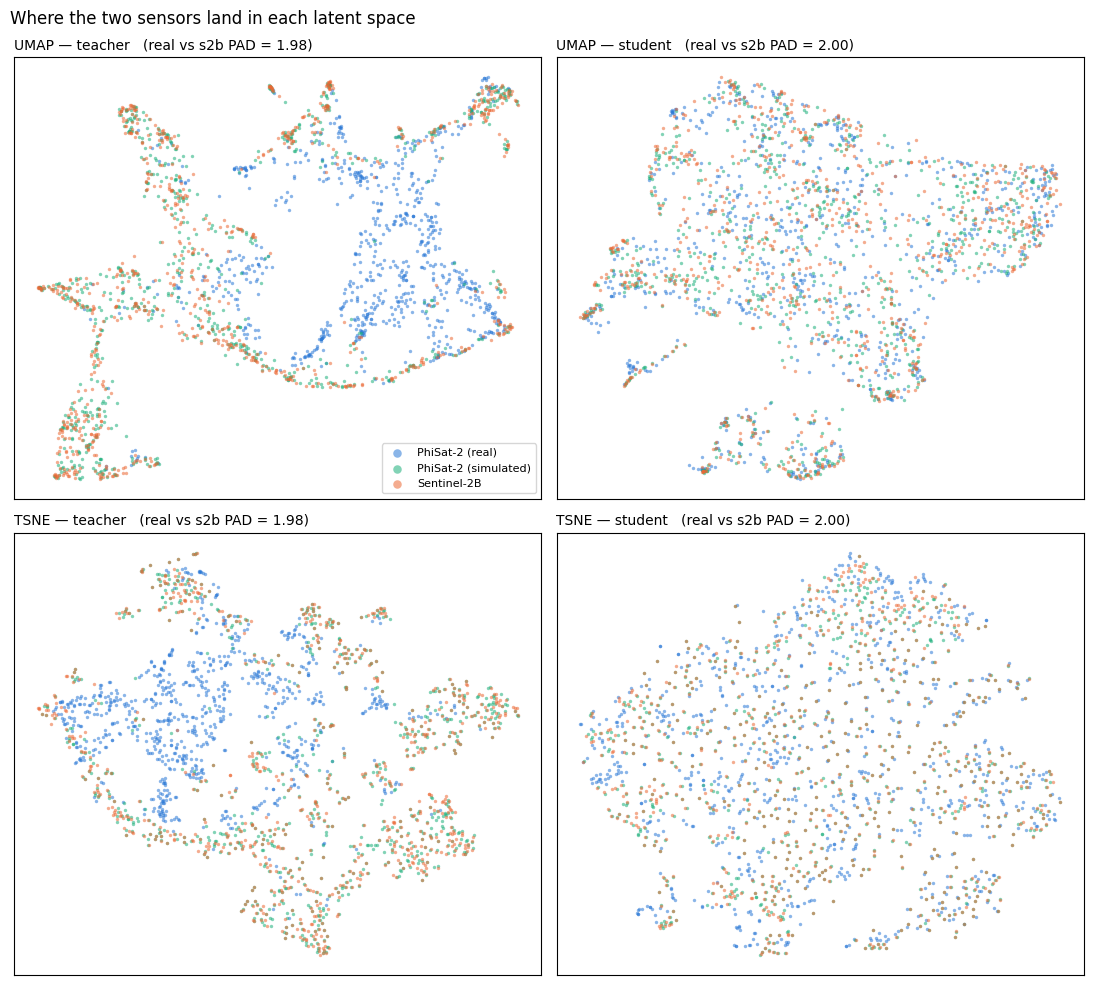

In [13]:
import umap
from sklearn.manifold import TSNE

DOMS = ("real", "sim", "s2b")


def project(e, how="umap", seed=0):
    X = np.vstack([e[d] for d in DOMS])
    X = StandardScaler().fit_transform(X)
    if how == "umap":
        Z = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=seed).fit_transform(X)
    else:
        Z = TSNE(n_components=2, perplexity=30, init="pca", random_state=seed).fit_transform(X)
    return np.split(Z, np.cumsum([len(e[d]) for d in DOMS])[:-1])


fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for row, how in enumerate(("umap", "tsne")):
    for col, model in enumerate(("teacher", "student")):
        ax = axes[row][col]
        for d, Z in zip(DOMS, project(emb[model], how)):
            ax.scatter(Z[:, 0], Z[:, 1], s=6, alpha=0.55, linewidths=0,
                       c=DOMAIN_COLOR[d], label=DOMAIN_LABEL[d])
        pad = tbl[(tbl.model == model) & (tbl.pair == "real vs s2b")]["PAD"].iloc[0]
        ax.set_title(f"{how.upper()} — {model}   (real vs s2b PAD = {pad:.2f})",
                     loc="left", fontsize=10)
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        if row == 0 and col == 0:
            ax.legend(markerscale=2.5, fontsize=8)
fig.suptitle("Where the two sensors land in each latent space", x=0.01, ha="left")
fig.tight_layout()
plt.show()

## 7. Per-layer divergence in the teacher

The teacher is a ViT, so the gap can be traced with depth: early blocks are
closer to raw radiometry, later blocks closer to semantics. If the gap only
opens up late, the mismatch is semantic; if it is present from block 1, it is
radiometric and input normalisation is the place to fix it.

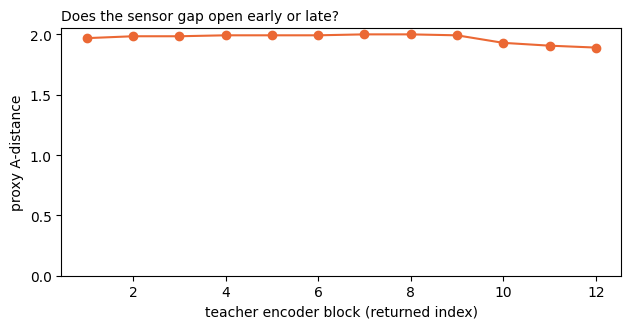

PAD per layer: [1.969 1.984 1.984 1.992 1.992 1.992 2.    2.    1.992 1.93  1.906 1.891]


In [14]:
@torch.no_grad()
def teacher_layer_embeddings(n=256, batch=BATCH):
    acc = {"real": None, "s2b": None}
    for start in range(0, min(n, len(ds_real)), batch):
        sl = range(start, min(start + batch, n))
        xs = {"real": torch.stack([ds_real[i]["image_target"] for i in sl]).to(device),
              "s2b": torch.stack([ds_real[i]["image_source"] for i in sl]).to(device)}
        for d, x in xs.items():
            layers = teacher.encoder({"S2L1C": x})
            pooled = [_pool(l).float().cpu().numpy() for l in layers]
            acc[d] = pooled if acc[d] is None else [np.vstack([a, b]) for a, b in zip(acc[d], pooled)]
    return acc


lay = teacher_layer_embeddings()
pads = [proxy_a_distance(a, b)[0] for a, b in zip(lay["real"], lay["s2b"])]

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.plot(range(1, len(pads) + 1), pads, marker="o", color="#eb6834")
ax.set_xlabel("teacher encoder block (returned index)")
ax.set_ylabel("proxy A-distance")
ax.set_ylim(0, 2.05)
ax.set_title("Does the sensor gap open early or late?", loc="left", fontsize=10)
fig.tight_layout()
plt.show()
print("PAD per layer:", np.round(pads, 3))

## 8. Summary — DSBN student vs teacher (800 test patches)

| model | PAD raw | PAD per-domain std | paired cos | probe s2b→s2b | probe s2b→real | retention |
|---|---|---|---|---|---|---|
| teacher | 1.955 | −1.07 | 0.098 | 0.754 | 0.250 | **33%** |
| student (DSBN) | **2.000** | −0.84 | 0.948 | 0.663 | **0.646** | **97%** |

**Do not read PAD=2 as a failure.** It is the per-domain BatchNorm affine, which
DSBN adds on purpose. Standardising each domain on its own moments drops the
domain classifier to chance for *both* models, so all of the raw separability was
first/second moment offset, not structure.

**The student's latent space is functionally domain-invariant; the teacher's is
not.** A linear classifier fitted on Sentinel-2 embeddings keeps **97%** of its
accuracy when applied to PhiSat-2 embeddings of the same ground (0.663 → 0.646).
The same test on the teacher keeps **33%** (0.754 → 0.250). This agrees with
paired cosine (0.948 vs 0.098) and with the IoU domain gap measured during
training (0.0217 on test), and it is the operational meaning of the claim.

The teacher remains the stronger encoder *within* Sentinel-2 (same-domain probe
0.754 vs 0.663) — it simply does not carry across the sensor gap.

**Caveat on framing.** With DSBN the encoder is domain-*adaptive*: convolutional
weights are shared, normalisation statistics are not, and the target branch must
be selected at inference (`set_domain(model, 1)`). That is a weaker claim than a
single domain-invariant encoder, and the thesis should state it that way.

**Rare classes.** In an 800-patch sample the dominant-class labels are dominated
by the common classes (mangroves 2 patches, moss/lichen 1, snow/ice 6), so the
probe accuracies describe the common classes. Raise `N_SAMPLES` before quoting
per-class transfer.
